# 13주차 실습

## 준비사항
- 다운로드: https://www.data.go.kr/data/15007122/fileData.do
- Google 드라이브 업로드: 드라이브/workspace/lecture/data/13W/Medical_checkup_2024.csv(파일이름 변경)
- 실습 전 구글드라이브 연결


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/workspace/lecture/data/13W/Medical_checkup_2024.csv', encoding='cp949')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   기준년도           1000000 non-null  int64  
 1   가입자일련번호        1000000 non-null  int64  
 2   시도코드           1000000 non-null  int64  
 3   성별코드           1000000 non-null  int64  
 4   연령대코드(5세단위)    1000000 non-null  int64  
 5   신장(5cm단위)      1000000 non-null  int64  
 6   체중(5kg단위)      1000000 non-null  int64  
 7   허리둘레           999505 non-null   float64
 8   시력(좌)          999807 non-null   float64
 9   시력(우)          999808 non-null   float64
 10  청력(좌)          999852 non-null   float64
 11  청력(우)          999852 non-null   float64
 12  수축기혈압          994210 non-null   float64
 13  이완기혈압          994211 non-null   float64
 14  식전혈당(공복혈당)     994153 non-null   float64
 15  총콜레스테롤         342400 non-null   float64
 16  트리글리세라이드       342395 non-null   float64
 17  HDL콜레스테롤 

In [20]:
# 컬럼명 변경 매핑 딕셔너리
column_mapping = {
    '기준년도': 'year',
    '가입자일련번호': 'id',
    '시도코드': 'city_code',
    '성별코드': 'gender',
    '연령대코드(5세단위)': 'age_group',
    '신장(5cm단위)': 'height',
    '체중(5kg단위)': 'weight',
    '허리둘레': 'waist',
    '시력(좌)': 'sight_left',
    '시력(우)': 'sight_right',
    '청력(좌)': 'hear_left',
    '청력(우)': 'hear_right',
    '수축기혈압': 'systolic_bp',
    '이완기혈압': 'diastolic_bp',
    '식전혈당(공복혈당)': 'fasting_blood_sugar',
    '총콜레스테롤': 'total_cholesterol',
    '트리글리세라이드': 'triglyceride',
    'HDL콜레스테롤': 'hdl_cholesterol',
    'LDL콜레스테롤': 'ldl_cholesterol',
    '혈색소': 'hemoglobin',
    '요단백': 'urine_protein',
    '혈청크레아티닌': 'serum_creatinine',
    '혈청지오티(AST)': 'ast',
    '혈청지피티(ALT)': 'alt',
    '감마지티피': 'gtp',
    '흡연상태': 'smoking_status',
    '음주여부': 'drinking_status',
    '구강검진수검여부': 'oral_checkup',
    '치아우식증유무': 'dental_caries',
    '결손치 유무': 'missing_tooth',
    '치아마모증유무': 'tooth_abrasion',
    '제3대구치(사랑니) 이상': 'wisdom_tooth_abnormality',
    '치석': 'tartar'
}

# 컬럼명 일괄 변경
df.rename(columns=column_mapping, inplace=True)

# 변경 결과 확인
print(df.columns)

Index(['year', 'id', 'city_code', 'gender', 'age_group', 'height', 'weight',
       'waist', 'sight_left', 'sight_right', 'hear_left', 'hear_right',
       'systolic_bp', 'diastolic_bp', 'fasting_blood_sugar',
       'total_cholesterol', 'triglyceride', 'hdl_cholesterol',
       'ldl_cholesterol', 'hemoglobin', 'urine_protein', 'serum_creatinine',
       'ast', 'alt', 'gtp', 'smoking_status', 'drinking_status',
       'oral_checkup', 'dental_caries', 'missing_tooth', 'tooth_abrasion',
       'wisdom_tooth_abnormality', 'tartar'],
      dtype='object')


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   year                      1000000 non-null  int64  
 1   id                        1000000 non-null  int64  
 2   city_code                 1000000 non-null  int64  
 3   gender                    1000000 non-null  int64  
 4   age_group                 1000000 non-null  int64  
 5   height                    1000000 non-null  int64  
 6   weight                    1000000 non-null  int64  
 7   waist                     999505 non-null   float64
 8   sight_left                999807 non-null   float64
 9   sight_right               999808 non-null   float64
 10  hear_left                 999852 non-null   float64
 11  hear_right                999852 non-null   float64
 12  systolic_bp               994210 non-null   float64
 13  diastolic_bp              99

## 치과 관련 및 의미 없는 컬럼 삭제

In [22]:
cols_to_drop = [
    'id', 'oral_checkup', 'dental_caries', 'missing_tooth',
    'tooth_abrasion', 'wisdom_tooth_abnormality', 'tartar'
]

# 존재하는 컬럼만 선별하여 삭제
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"삭제 후 남은 컬럼 수: {len(df.columns)}")
df.head()

삭제 후 남은 컬럼 수: 26


,year,city_code,gender,age_group,height,weight,waist,sight_left,sight_right,hear_left,...,hdl_cholesterol,ldl_cholesterol,hemoglobin,urine_protein,serum_creatinine,ast,alt,gtp,smoking_status,drinking_status
0,2024,41,2,13,160,50,70.0,1.0,1.0,1.0,...,NaN,NaN,14.7,1.0,0.8,26.0,13.0,6.0,1.0,1.0
1,2024,41,2,11,155,60,74.9,1.0,1.0,1.0,...,NaN,NaN,12.7,1.0,0.8,19.0,10.0,14.0,1.0,1.0
2,2024,41,2,13,150,55,74.0,1.0,1.0,1.0,...,NaN,NaN,13.7,1.0,0.8,27.0,19.0,17.0,1.0,1.0
3,2024,41,1,16,160,70,89.0,1.0,1.0,1.0,...,NaN,NaN,15.6,1.0,0.8,26.0,26.0,28.0,1.0,1.0
4,2024,41,1,11,175,65,76.0,1.0,1.0,1.0,...,NaN,NaN,14.8,1.0,0.8,18.0,18.0,12.0,1.0,1.0


## 결측지 처리

- 결측치가 50% 이상인 컬럼 삭제
- 남은 데이터에서 결측치가 있는 행(row)를 삭제

In [23]:
missing_ratio = df.isnull().mean()

cols_over_50 = missing_ratio[missing_ratio >= 0.5].index.tolist()
df = df.drop(columns=cols_over_50)
print(f"50% 이상 결측으로 삭제된 컬럼: {cols_over_50}")

before_count = len(df)
df = df.dropna()
after_count = len(df)

print(f"결측치 행 제거 완료: {before_count - after_count}개의 행이 삭제되었습니다.")
print(f"현재 남은 데이터 건수: {len(df)}")

50% 이상 결측으로 삭제된 컬럼: ['total_cholesterol', 'triglyceride', 'hdl_cholesterol', 'ldl_cholesterol']
결측치 행 제거 완료: 12267개의 행이 삭제되었습니다.
현재 남은 데이터 건수: 987733


## 이상치 제거

- IQR 범위를 3.0으로 확장

In [24]:
def remove_extreme_outliers(df, columns):
  for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # 1.5 대신 3.0을 사용하여 "극단적" 이상치만 제거
    lower_bound = Q1 - 3.0 * IQR
    upper_bound = Q3 + 3.0 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# 수치형 변수에 대해 적용
numerical_cols = ['waist', 'systolic_bp', 'diastolic_bp', 'fasting_blood_sugar', 'hemoglobin']
df = remove_extreme_outliers(df, numerical_cols)
print(f"3.0 IQR 적용 후 남은 데이터: {len(df)}")

3.0 IQR 적용 후 남은 데이터: 987627


## EDA

In [9]:
# Colab에서 한글 폰트 설정을 위한 코드
!apt-get update -qq # apt 패키지 리스트 업데이트
!apt-get install -y fonts-nanum # 나눔 폰트 설치

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 폰트 경로
fm.fontManager.addfont(fontpath) # 폰트 매니저에 폰트 추가
plt.rcParams['font.family'] = 'NanumBarunGothic' # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("한글 폰트 'NanumBarunGothic'이(가) 설정되었습니다.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 22 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,057 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
한글 폰트 'NanumBarunGothic'이(가) 설정되었

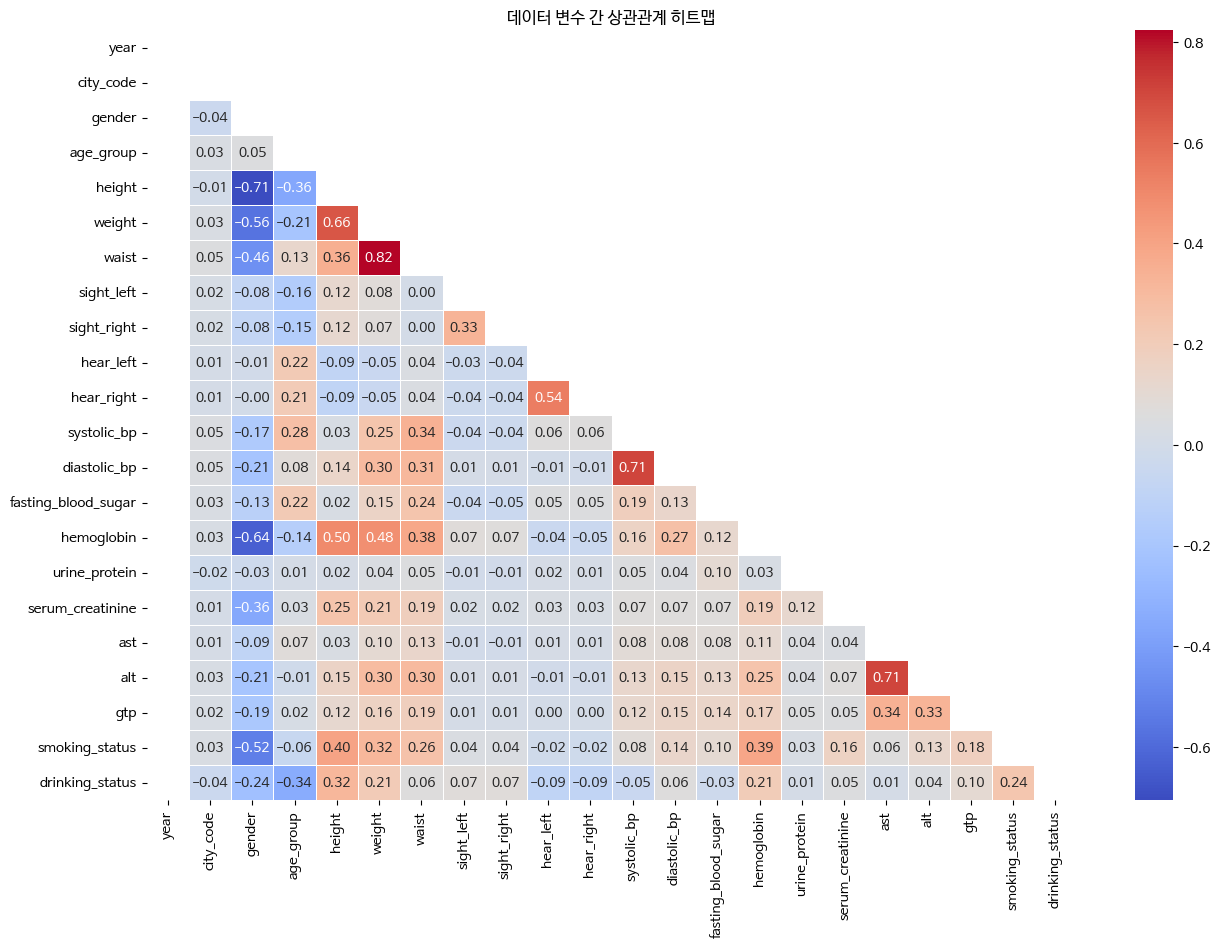

In [25]:
import seaborn as sns
import numpy as np

# 상관계수 계산
corr_matrix = df.corr()

# 히트맵(시각화)
plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 상단 삼각형 가리기

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", mask=mask,
            linewidth=0.5)
plt.title("데이터 변수 간 상관관계 히트맵")
plt.show()

In [34]:
# 상관관계 확인
cols = corr_matrix.columns

for i in range(len(cols)):
  for j in range(i + 1, len(cols)):
    v1 = cols[i]
    v2 = cols[j]
    correlation = corr_matrix.loc[v1, v2]

    # 상관관계가 0.7 보다 크다면 출력(절대값)
    if abs(correlation) >= 0.7:
      print(f"{v1}과 {v2}는 관계가 큼: {correlation:.4f}")

gender과 height는 관계가 큼: -0.7060
weight과 waist는 관계가 큼: 0.8228
systolic_bp과 diastolic_bp는 관계가 큼: 0.7061
ast과 alt는 관계가 큼: 0.7057


In [35]:
# 타겟과의 상관관계가 큰 변수 추출 -> 모델링에 필요한 변수 힌트
target_corr = corr_matrix['fasting_blood_sugar'].abs().sort_values(ascending=False)

print("당뇨 위험도와 상관관계가 높은 변수 TOP 10")
print(target_corr.head(11))

당뇨 위험도와 상관관계가 높은 변수 TOP 10
fasting_blood_sugar    1.000000
waist                  0.244060
age_group              0.217188
systolic_bp            0.185041
weight                 0.150196
gtp                    0.138122
diastolic_bp           0.133723
alt                    0.127233
gender                 0.126305
hemoglobin             0.121403
smoking_status         0.103087
Name: fasting_blood_sugar, dtype: float64


In [36]:
final_drop_cols = [
    'weight',              # waist와 중복
    'height',              # gender와 중복
    'year', 'city_code',   # 의미 없는 식별자
    'sight_left', 'sight_right', 'hear_left', 'hear_right' # 무의미한 변수들
]

df_cleaned = df.drop(columns=final_drop_cols)
print("모델 학습에 사용할 변수")
print(df_cleaned.columns)

모델 학습에 사용할 변수
Index(['gender', 'age_group', 'waist', 'systolic_bp', 'diastolic_bp',
       'fasting_blood_sugar', 'hemoglobin', 'urine_protein',
       'serum_creatinine', 'ast', 'alt', 'gtp', 'smoking_status',
       'drinking_status'],
      dtype='object')


## 피처 엔지니어링

- 복부비만여부
- 평균 동맥압(MAP)
- 간기능 통합지표

In [37]:
# 1. 복부 비만 여부(성별: 남성 - 1 / 여성 - 2)
def check_obesity(row):
  if row['gender'] == 1:
    return 1 if row['waist'] >= 90 else 0
  else:
    return 1 if row['waist'] >= 85 else 0

df_cleaned['is_abdominal_obesity'] = df_cleaned.apply(check_obesity, axis=1)

# 2. 평균 동맥압
df_cleaned['MAP'] = (df_cleaned['systolic_bp'] + 2 * df_cleaned['diastolic_bp']) / 3

# 3. 간 기능 통합 지표
df_cleaned['liver_index'] = df_cleaned['alt'] + df_cleaned['gtp']

In [42]:
drop_cols = ['diastolic_bp']
df_final = df_cleaned.drop(columns=drop_cols)
display(df_final.head())

,gender,age_group,waist,systolic_bp,fasting_blood_sugar,hemoglobin,urine_protein,serum_creatinine,ast,alt,gtp,smoking_status,drinking_status,is_abdominal_obesity,MAP,liver_index
0,2,13,70.0,107.0,70.0,14.7,1.0,0.8,26.0,13.0,6.0,1.0,1.0,0,87.000000,19.0
1,2,11,74.9,104.0,81.0,12.7,1.0,0.8,19.0,10.0,14.0,1.0,1.0,0,80.666667,24.0
2,2,13,74.0,134.0,106.0,13.7,1.0,0.8,27.0,19.0,17.0,1.0,1.0,0,100.000000,36.0
3,1,16,89.0,119.0,97.0,15.6,1.0,0.8,26.0,26.0,28.0,1.0,1.0,0,88.333333,54.0
4,1,11,76.0,103.0,115.0,14.8,1.0,0.8,18.0,18.0,12.0,1.0,1.0,0,77.000000,30.0


## 데이터 셋 준비

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_final['target'] = (df_final['fasting_blood_sugar'] >= 110).astype(int)

X = df_final.drop(columns=['fasting_blood_sugar', 'target'])
y = df_final['target']

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 셋 분리: 학습용 / 테스트용
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print("데이터 분리 및 스케일링 완료!")
print(f"학습 데이터 형태: {X_train.shape}, 타겟 위험군 비율: {y.mean():.2%}")

데이터 분리 및 스케일링 완료!
학습 데이터 형태: (790101, 15), 타겟 위험군 비율: 19.24%


# 데이터 불균형 처리

- 언더샘플링 수행

In [44]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("--- [언더샘플링 결과] ---")
print(f"기존 학습 데이터 크기: {X_train.shape}")
print(f"언더샘플링 후 데이터 크기: {X_train_under.shape}")
print(f"타겟 비율 확인:\n{y_train_under.value_counts(normalize=True)}")

--- [언더샘플링 결과] ---
기존 학습 데이터 크기: (790101, 15)
언더샘플링 후 데이터 크기: (303954, 15)
타겟 비율 확인:
target
0    0.5
1    0.5
Name: proportion, dtype: float64


In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC # SVC보다 훨씬 빠른 선형 SVM입니다.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import pandas as pd
import time

X_train_sample = X_train_under
y_train_sample = y_train_under

models = [
    ("Decision Tree", DecisionTreeClassifier(max_depth=5)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, n_jobs=-1)),
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Linear SVM", LinearSVC(max_iter=1000, dual=False)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("Naive Bayse", GaussianNB())
]

results = []

for name, model in models:
  start_time = time.time()

  # 모델 학습
  model.fit(X_train_sample, y_train_sample)
  # 예측
  y_pred = model.predict(X_test)

  # 평가지표 계산
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred)

  elapsed_time = time.time() - start_time

  results.append([name, recall, f1, auc, elapsed_time])
  print(f"{name} 완료! (소요시간: {elapsed_time:.2f})")

# 결과 비교
result_df = pd.DataFrame(results, columns=['Model', 'Recall', 'F1-Score', 'ROC-AUC', 'Time(s)'])
print("\n--- [모델 성능 비교 결과] ---")
print(result_df.sort_values(by='Recall', ascending=False))

Decision Tree 완료! (소요시간: 1.64)
Random Forest 완료! (소요시간: 76.66)
Logistic Regression 완료! (소요시간: 0.93)
Linear SVM 완료! (소요시간: 0.77)
KNN 완료! (소요시간: 452.24)
Naive Bayse 완료! (소요시간: 0.20)

--- [모델 성능 비교 결과] ---
                 Model    Recall  F1-Score   ROC-AUC     Time(s)
0        Decision Tree  0.783840  0.446440  0.686183    1.636874
1        Random Forest  0.760363  0.462777  0.698493   76.664957
3           Linear SVM  0.735807  0.461105  0.694555    0.770971
2  Logistic Regression  0.726201  0.461139  0.693597    0.934106
4                  KNN  0.675826  0.425080  0.658819  452.239369
5          Naive Bayse  0.375628  0.374220  0.612565    0.202984


In [49]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
import time

boosting_models = [
    ("XGBoost", XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                              tree_method='hist', random_state=42)),
    ("LgithGBM", LGBMClassifier(n_estimators=100, learning_rate=0.1,
                                importance_type='gain', random_state=42))
]

for name, model in boosting_models:
  start = time.time()

  model.fit(X_train_sample, y_train_sample)

  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:, 1]

  auc = roc_auc_score(y_test, y_prob)
  elapsed = time.time() - start

  print(f"{name} 완료! (AUC: {auc:.4f}, 시간: {elapsed:.2f}s)")
  print(classification_report(y_test, y_pred))

XGBoost 완료! (AUC: 0.7756, 시간: 7.16s)
              precision    recall  f1-score   support

           0       0.92      0.63      0.75    159531
           1       0.33      0.79      0.47     37995

    accuracy                           0.66    197526
   macro avg       0.63      0.71      0.61    197526
weighted avg       0.81      0.66      0.69    197526

[LightGBM] [Info] Number of positive: 151977, number of negative: 151977
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1938
[LightGBM] [Info] Number of data points in the train set: 303954, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LgithGBM 완료! (AUC: 0.7762, 시간: 9.23s)
              precision    recall  f1-score   support

           0       0.92      0.63      0.75    159531
           1       0.34      0.78      0.47     37995

    accuracy                           0.66    197526
   macro avg       0.63      0.71      0.61    197526
weighted avg       0.81      0.66      0.70    197526

